<a href="https://colab.research.google.com/github/codewithadityard/employee-attrition-prediction/blob/main/02_visualization_and_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Visualisation

In [ ]:
df=pd.read_csv("cleaned_file_employee.csv")

In [ ]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'Travel_Frequently', 'Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree',
       'Human Resources', 'Laboratory Technician', 'Manager',
       'Manufacturing Director', 'Research Director', 'Research Scientist',
       'Sales Executive', 'Sales Representative'],
      dty

## HeatMap

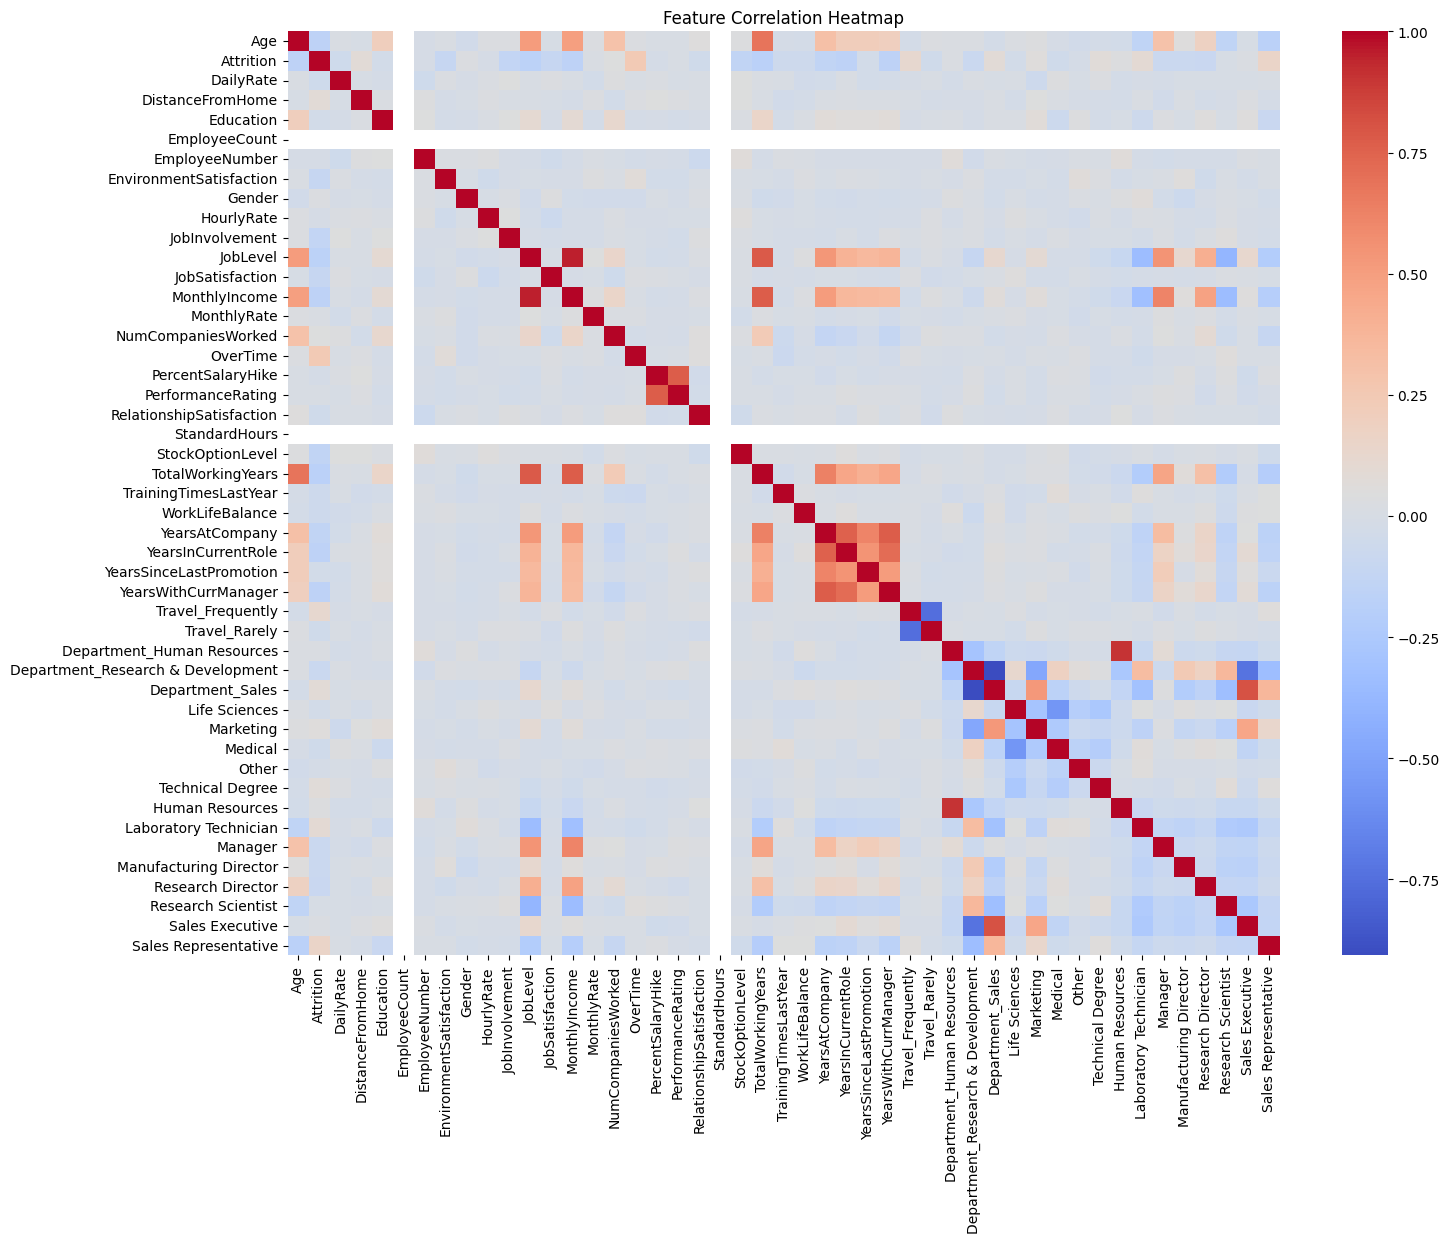

In [ ]:
plt.figure(figsize=(16,12))

corr_matrix=df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)

plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
df.drop("EmployeeNumber",axis=1,inplace=True)

In [ ]:
def columns_to_drop(df,threshold):
    corr_matrix=df.corr().abs()
    to_drop=set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i,j]>threshold:
                col_name=corr_matrix.columns[i]
                to_drop.add(col_name)
    return df.drop(columns=to_drop)
df=columns_to_drop(df,0.85)

In [ ]:
df.shape

(1470, 43)

In [ ]:
df.columns

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Travel_Frequently',
       'Travel_Rarely', 'Department_Human Resources',
       'Department_Research & Development', 'Life Sciences', 'Marketing',
       'Medical', 'Other', 'Technical Degree', 'Laboratory Technician',
       'Manager', 'Manufacturing Director', 'Research Director',
       'Research Scientist', 'Sales Executive', 'Sales Representative'],
      dtype='object')

## Histogram ( Number of Employees and thier age)

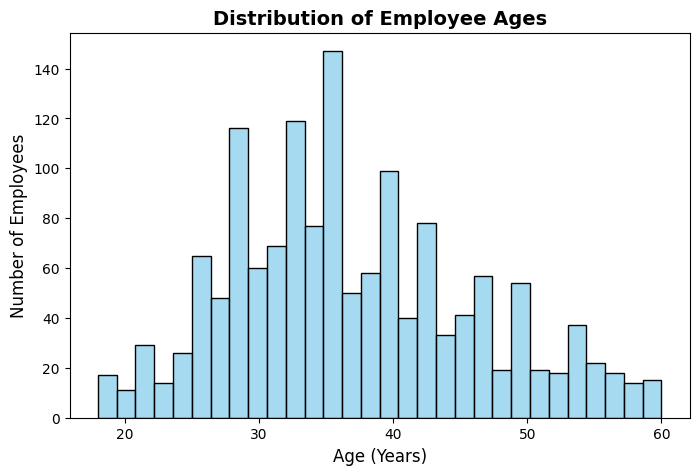

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# A simple histogram showing only the distribution of Employee Ages
sns.histplot(data=df, x='Age', bins=30, color='skyblue')

plt.title('Distribution of Employee Ages', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

plt.show()

## Line PLot ( Salary Hike vs years in Company)

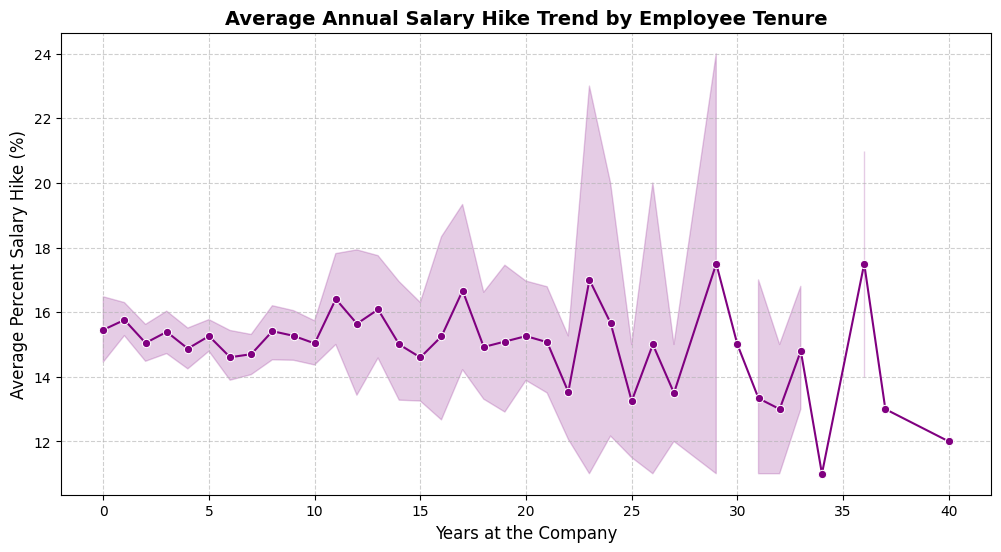

In [ ]:
plt.figure(figsize=(12, 6))

# X-axis: Years At Company (Sequential)
# Y-axis: Percent Salary Hike (Continuous)
sns.lineplot(data=df, x='YearsAtCompany', y='PercentSalaryHike', color='purple', marker='o')

plt.title('Average Annual Salary Hike Trend by Employee Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Years at the Company', fontsize=12)
plt.ylabel('Average Percent Salary Hike (%)', fontsize=12)

# Optional: Add a grid to make reading the exact percentages easier
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## Pie Chart (Percentage of people working Overtime vs people not working Overtime)

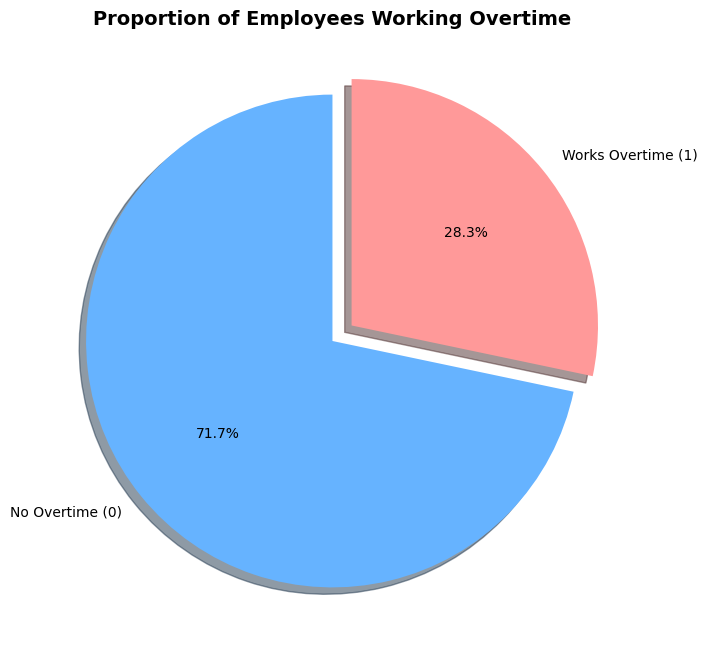

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))

# Count how many employees fall into the 0 (No) and 1 (Yes) categories
overtime_counts = df['OverTime'].value_counts()

# Create the pie chart
plt.pie(overtime_counts,
        labels=['No Overtime (0)', 'Works Overtime (1)'],
        autopct='%1.1f%%', # Shows the percentage formatted to 1 decimal place
        startangle=90,     # Rotates the starting point for a cleaner look
        colors=['#66b3ff', '#ff9999'],
        explode=(0, 0.1),  # Slightly separates the "Overtime" slice for emphasis
        shadow=True)

plt.title('Proportion of Employees Working Overtime', fontsize=14, fontweight='bold')
plt.show()

## Bar Chart

C:\Users\Admin\AppData\Local\Temp\ipykernel_9504\2777132221.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='EnvironmentSatisfaction', y='Attrition', palette='viridis')


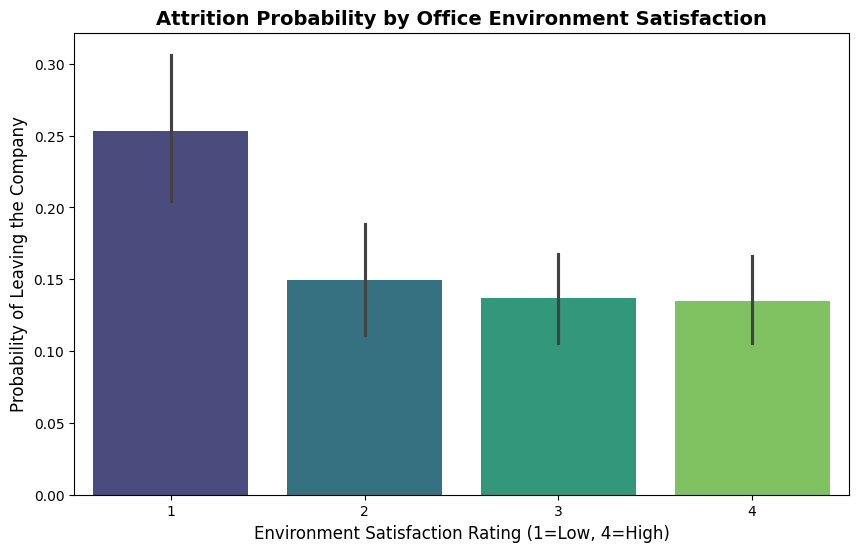

In [ ]:
plt.figure(figsize=(10, 6))

# X-axis: Environment Satisfaction (1 = Low, 4 = High)
# Y-axis: Attrition (Since it's 0 and 1, sns.barplot automatically calculates the % rate)
sns.barplot(data=df, x='EnvironmentSatisfaction', y='Attrition', palette='viridis')

plt.title('Attrition Probability by Office Environment Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Environment Satisfaction Rating (1=Low, 4=High)', fontsize=12)
plt.ylabel('Probability of Leaving the Company', fontsize=12)

plt.show()

## Model Training

In [ ]:
y=df["Attrition"]
X=df.drop("Attrition",axis=1)

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
y_train_smote.value_counts()

Attrition
0    986
1    986
Name: count, dtype: int64

In [ ]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Model
# From scikit-learn
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# From XGBoost
from xgboost import XGBClassifier

## Training XgBoost,Decision Tree and Random forest , Printing all metrices like confusion matrix,accuracy, classification Report

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(device='cuda', tree_method='hist', random_state=42)
}

# 2. Loop through the dictionary to train and evaluate each model
for model_name, model in models.items():

    print(f"========== {model_name} ==========")

    # Train the model on the balanced SMOTE data
    model.fit(X_train_smote, y_train_smote)

    # Make predictions on the unseen test data
    y_pred = model.predict(X_test)

    # Calculate and print metrics
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\n" + "="*40 + "\n")

========== Decision Tree ==========
Accuracy: 74.83%

Confusion Matrix:
[[208  39]
 [ 35  12]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       247
           1       0.24      0.26      0.24        47

    accuracy                           0.75       294
   macro avg       0.55      0.55      0.55       294
weighted avg       0.76      0.75      0.75       294



========== Random Forest ==========
Accuracy: 84.69%

Confusion Matrix:
[[238   9]
 [ 36  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.55      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.71      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



========== XGBoost ==========
Accuracy: 84.01%

Confusion Matrix:
[[228  19]
 [ 28  19]]

Classification

C:\Users\Admin\ml2\envs\pytorch\lib\site-packages\xgboost\core.py:751: UserWarning: [01:37:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
